## GAN

Device        : cuda
PyTorch       : 2.10.0+cu128
torch.compile : YES
Fused Adam    : YES
AMP (autocast): YES (Transformer only)
TF32          : YES
Data dir      : /content/

MODULE 2 — FRA Data Extraction

Verifying files...
  ✓ Healthy_Case_Data.xlsx
  ✓ Healthy_perturb_plus_one_percentage.xlsx
  ✓ Healthy_perturb_plus_two_percentage.xlsx
  ✓ Healthy_perturb_minus_one_percentage.xlsx
  ✓ Healthy_perturb_minus_two_percentage.xlsx
  ✓ Axial_Fault_plus_5.xlsx
  ✓ Axial_Fault_minus_5.xlsx
  ✓ Axial_Fault_plus_10.xlsx
  ✓ Axial_Fault_minus_10.xlsx
  ✓ Axial_Fault_plus_25.xlsx
  ✓ Axial_Fault_minus_25.xlsx
  ✓ Axial_Fault_plus_50.xlsx
  ✓ Axial_Fault_minus_50.xlsx
  ✓ Radial_Fault_plus_5.xlsx
  ✓ Radial_Fault_minus_5.xlsx
  ✓ Radial_Fault_plus_10.xlsx
  ✓ Radial_Fault_minus_10.xlsx
  ✓ Radial_Fault_plus_25.xlsx
  ✓ Radial_Fault_minus_25.xlsx
  ✓ Radial_Fault_plus_50.xlsx

✓ All 20 files found

Extracting FRA curves...
  ✓ healthy_base        2001 pts  H(f) [-113.6, -21.6] dB
  ✓ healthy_p

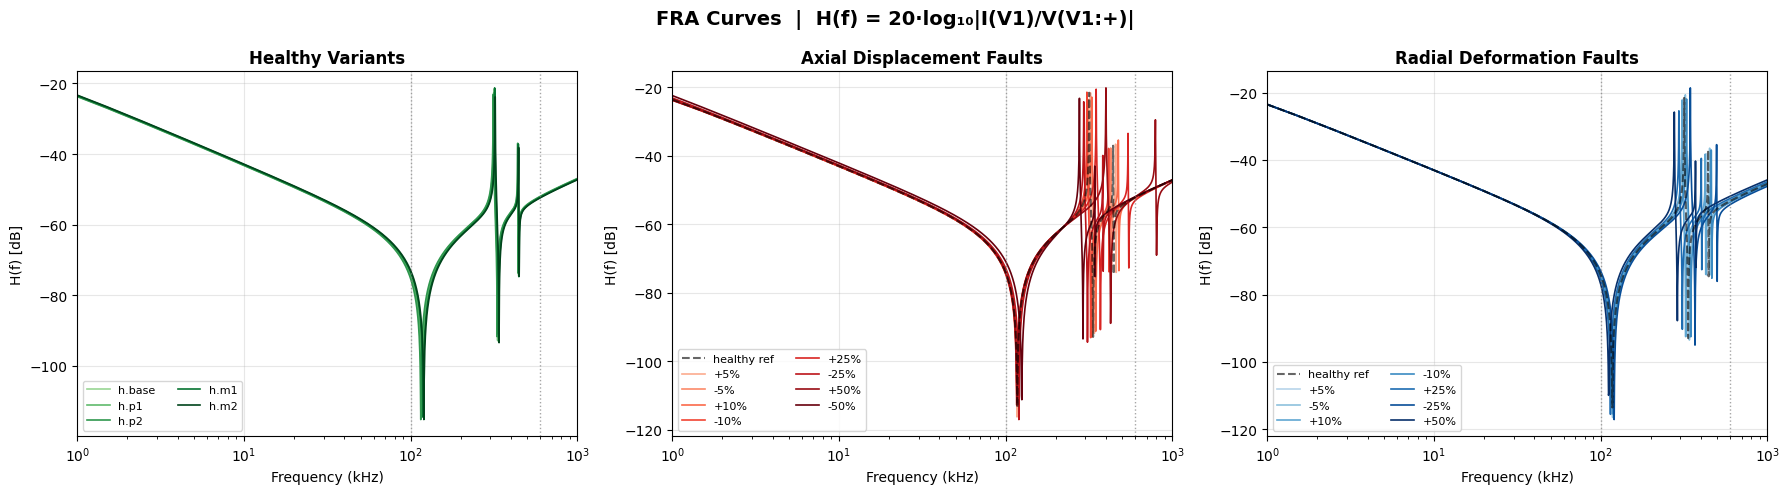

✓ FRA plot → results/FRA_curves.png

MODULE 3 — Indicator Calculator
Computing 48-D feature vectors...
  ✓ healthy_base        NaN=0  CC_LF=1.000000
  ✓ healthy_p1          NaN=0  CC_LF=1.000000
  ✓ healthy_p2          NaN=0  CC_LF=0.999999
  ✓ healthy_m1          NaN=0  CC_LF=1.000000
  ✓ healthy_m2          NaN=0  CC_LF=0.999999
  ✓ AD_plus5            NaN=0  CC_LF=0.999999
  ✓ AD_minus5           NaN=0  CC_LF=0.999999
  ✓ AD_plus10           NaN=0  CC_LF=0.999995
  ✓ AD_minus10          NaN=0  CC_LF=0.999996
  ✓ AD_plus25           NaN=0  CC_LF=0.999959
  ✓ AD_minus25          NaN=0  CC_LF=0.999982
  ✓ AD_plus50           NaN=0  CC_LF=0.999745
  ✓ AD_minus50          NaN=0  CC_LF=0.999953
  ✓ RD_plus5            NaN=0  CC_LF=1.000000
  ✓ RD_minus5           NaN=0  CC_LF=1.000000
  ✓ RD_plus10           NaN=0  CC_LF=1.000000
  ✓ RD_minus10          NaN=0  CC_LF=1.000000
  ✓ RD_plus25           NaN=0  CC_LF=0.999998
  ✓ RD_minus25          NaN=0  CC_LF=0.999998
  ✓ RD_plus50          

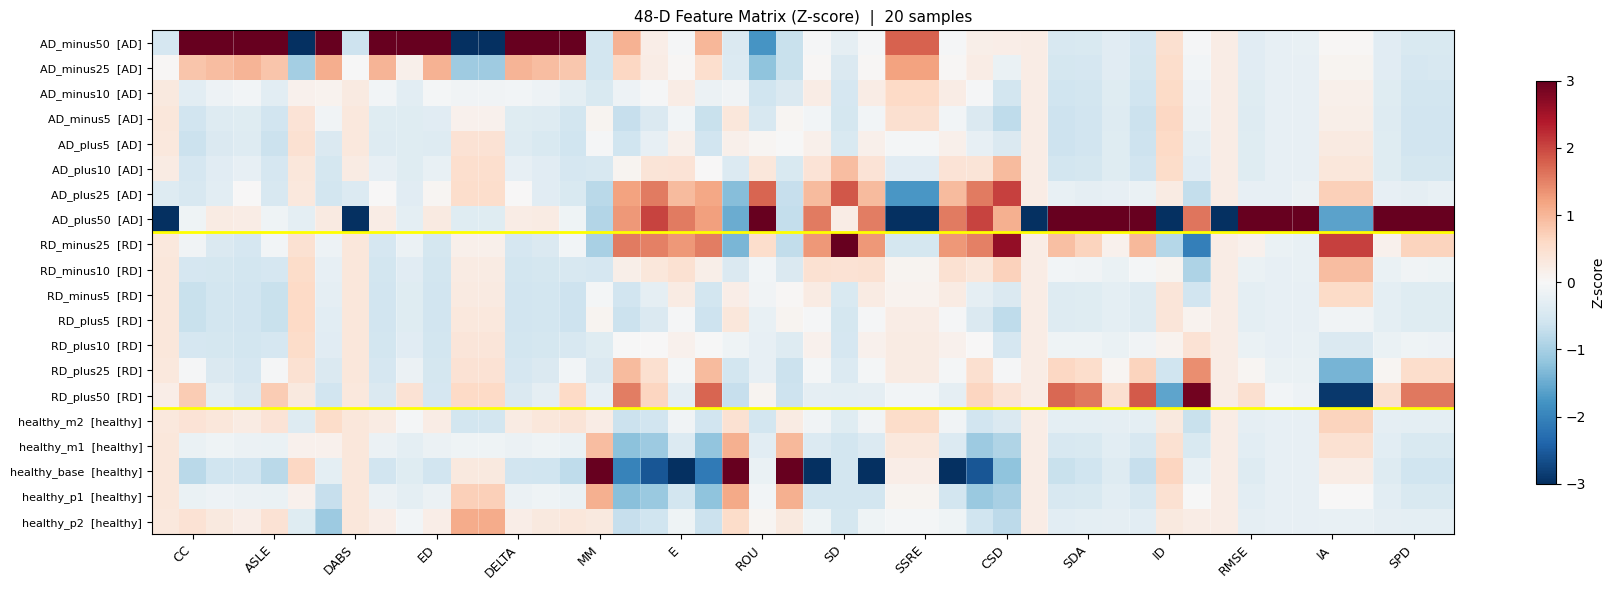

✓ Feature heatmap → results/feature_heatmap.png

MODULE 4 — SpectralGAN Architecture
✓ Generator  — 178,672 params
✓ Critic     — 160,961 params  (Spectral Norm on all layers)
  WGAN-GP  λ_GP=10.0
  Fold training: 200 epochs  N_critic=3  batch=128
  Full training: 600 epochs  N_critic=5  batch=128

MODULE 5 — Train Full SpectralGAN + Generate Dataset
Training full SpectralGAN (600 epochs, all 20 samples)...


W0418 03:51:41.442000 6812 torch/_inductor/utils.py:1679] [1/0] Not enough SMs to use max_autotune_gemm mode


    ep   75/600  G_loss=-2.4689  W_dist=0.7367
    ep  150/600  G_loss=-2.8418  W_dist=0.7860
    ep  225/600  G_loss=-2.8584  W_dist=0.3725
    ep  300/600  G_loss=-3.0057  W_dist=0.7677
    ep  375/600  G_loss=-2.9354  W_dist=0.1617
    ep  450/600  G_loss=-3.0408  W_dist=0.3088
    ep  525/600  G_loss=-2.8785  W_dist=0.3087
    ep  600/600  G_loss=-2.8338  W_dist=0.3121
✓ Done in 1.7 min
✓ Checkpoint → checkpoints/spectralgan_full.pt

Generating 1000 samples × 3 classes...
  healthy     mean=-0.155  std=0.622
  AD          mean=-0.002  std=0.698
  RD          mean=-0.017  std=0.621
✓ Augmented dataset → augmented/augmented_dataset.csv  (3020 rows)

Capturing loss history for diagnostic plot...


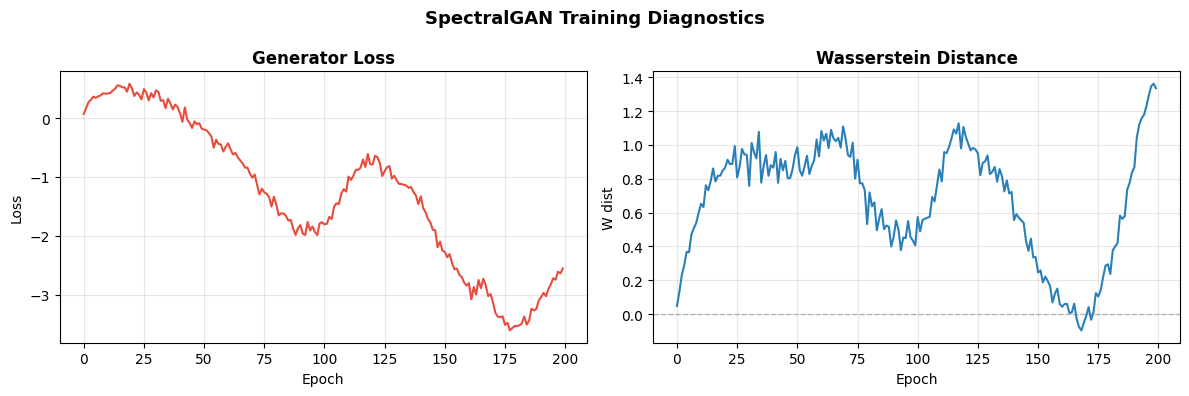

✓ GAN training curves → results/gan_training_curves.png

Running t-SNE...


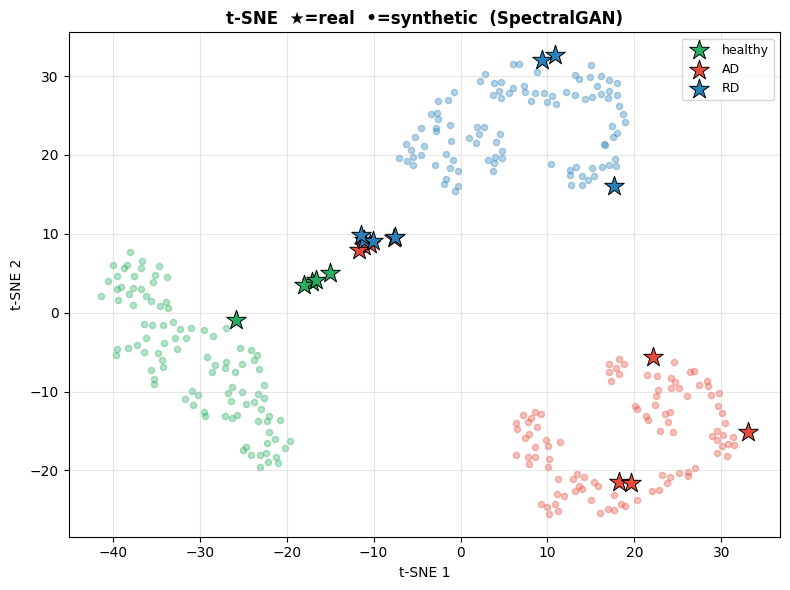

✓ t-SNE → results/tsne_synthetic_vs_real.png

MODULE 6 — FRATransformer Classifier
✓ FRATransformer — 70,659 params
  Training: GPU-native loop  AMP=YES  compile=YES

MODULE 7 — LOOCV Evaluation

Step 7.1 — SVM LOOCV (no augmentation, baseline)...
────────────────────────────────────────────────────────────
  Fold  1/20  healthy_base          true=healthy    pred=AD         ✗
  Fold  2/20  healthy_p1            true=healthy    pred=healthy    ✓
  Fold  3/20  healthy_p2            true=healthy    pred=healthy    ✓
  Fold  4/20  healthy_m1            true=healthy    pred=healthy    ✓
  Fold  5/20  healthy_m2            true=healthy    pred=healthy    ✓
  Fold  6/20  AD_plus5              true=AD         pred=RD         ✗
  Fold  7/20  AD_minus5             true=AD         pred=RD         ✗
  Fold  8/20  AD_plus10             true=AD         pred=AD         ✓
  Fold  9/20  AD_minus10            true=AD         pred=AD         ✓
  Fold 10/20  AD_plus25             true=AD         pred=AD  

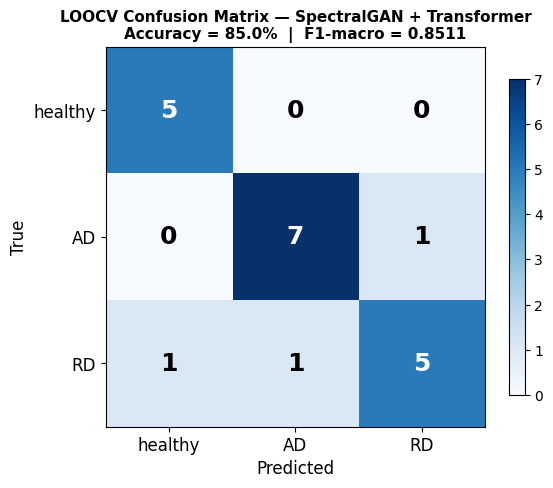

✓ Confusion matrix → results/confusion_matrix_loocv.png

Step 7.4 — Ablation Study (all LOOCV)
────────────────────────────────────────────────────────────
  SVM (linear)            acc=0.7000  F1=0.7131
  SVM (rbf)               acc=0.7000  F1=0.7131
  SVM (poly)              acc=0.1000  F1=0.1369
  KNN (k=3)               acc=0.4500  F1=0.4889
  KNN (k=5)               acc=0.4500  F1=0.4624

                      Model  Accuracy  F1 macro
SpectralGAN + Transformer ←      0.85  0.851107
               SVM (linear)      0.70  0.713095
                  SVM (rbf)      0.70  0.713095
                  KNN (k=3)      0.45  0.488889
                  KNN (k=5)      0.45  0.462393
                 SVM (poly)      0.10  0.136905
✓ Ablation → results/ablation_loocv.csv


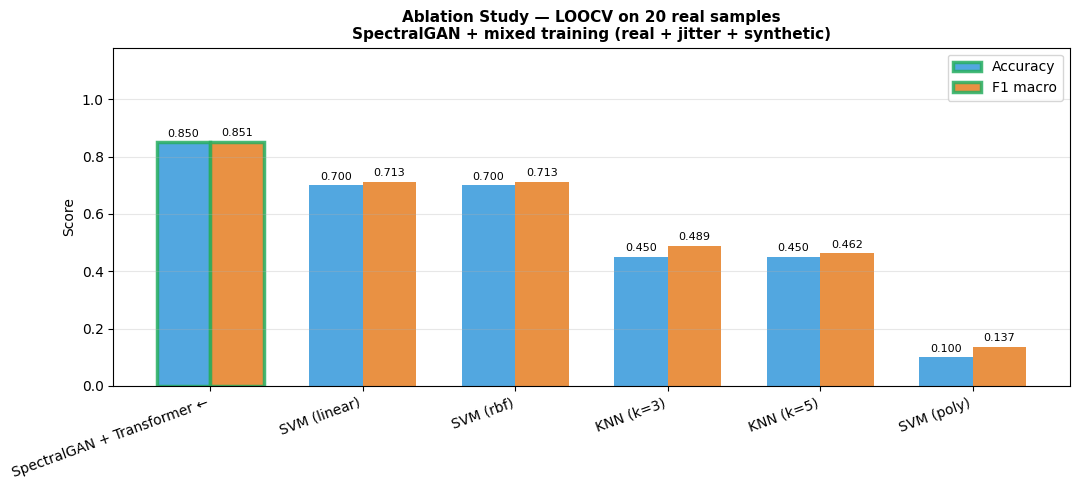

✓ Ablation chart → results/ablation_chart.png

╔══════════════════════════════════════════════════════════════════╗
║           FINAL RESULTS — HONEST LOOCV  (SpectralGAN v4)         ║
╠══════════════════════════════════════════════════════════════════╣
║  Evaluation   : Leave-One-Out CV  (20 folds)                     ║
║  Dataset      : 20 real  (5 healthy / 8 AD / 7 RD)               ║
║  GAN          : SpectralGAN  WGAN-GP + SN Critic                 ║
║  Classifier   : FRATransformer — mixed training                  ║
║  GPU opts     : compile=True  AMP=True  fused_adam=True          ║
╠══════════════════════════════════════════════════════════════════╣
║  Model                                Accuracy   F1 macro        ║
║  ──────────────────────────────────────────────────────────────  ║
║  SpectralGAN + Transformer ←            0.8500     0.8511        ║
║  SVM (linear)                           0.7000     0.7131        ║
║  SVM (rbf)                              0.7000     0.7

In [ ]:
# =============================================================================
#  CAPSTONE AI PIPELINE  —  Modules 2 through 7  (GAN VERSION  v4 — GPU OPT)
#  Run this in Google Colab (copy-paste entire file)
#
#  Upload all 20 xlsx files to /content/ before running.
#
#  GPU OPTIMISATIONS vs v3  (target: <1.5 min/fold  ≈  30 min total):
#   1. Manual GPU batching
#        All training tensors are moved to GPU ONCE at fold start and
#        never touched by Python/CPU again.  torch.randperm on GPU replaces
#        DataLoader's Python shuffle.  Eliminates per-batch CPU→GPU transfers
#        and DataLoader Python overhead — the #1 bottleneck for tiny datasets.
#   2. torch.compile (PyTorch ≥ 2.0)
#        Generator G is wrapped with torch.compile().  Critic C is NOT
#        compiled — torch.compile AOT autograd conflicts with WGAN-GP's
#        second-order gradient penalty.  Classifier IS compiled (no GP).
#   3. Fused Adam (CUDA kernels)
#        torch.optim.Adam(..., fused=True) runs a single CUDA kernel per
#        param group instead of one Python call per tensor.  ~10–15 % gain.
#   4. AMP for Transformer classifier (torch.autocast)
#        Half-precision forward pass for the Transformer — safe here because
#        GAN GP is not involved.  ~30–50 % speedup on T4 / A100.
#   5. Larger batch (128 everywhere)
#        Doubles GPU occupancy vs batch=64 for these model sizes.
#   6. Reduced fold hyperparams
#        GAN_EPOCHS_FOLD=200, N_CRITIC_FOLD=3  (vs 300 / 5 in v3)
#        Converges sufficiently given mixed training in the classifier.
#   7. GradScaler disabled for GAN  (gradient penalty ⊥ AMP)
#        Gradient penalty requires autograd.grad through interp samples;
#        this is not compatible with GradScaler.  GAN stays fp32 but
#        benefits from (1)–(3) and (5)–(6).
# =============================================================================

# ── 0. INSTALLS ───────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'openpyxl', 'torch', 'torchvision',
                'scikit-learn', 'pandas', 'numpy', 'matplotlib',
                '--quiet'], check=False)

# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import os, math, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
import matplotlib.cm as cm
warnings.filterwarnings('ignore')

try:    _trapz = np.trapezoid
except: _trapz = np.trapz

# =============================================================================
#  CONFIGURATION
# =============================================================================
DRIVE_PATH = '/content/'

SEED              = 42
N_PER_CLASS       = 1000   # synthetic samples per class for full-data GAN
GAN_EPOCHS_FULL   = 600    # epochs for full-data run (t-SNE / export)
GAN_EPOCHS_FOLD   = 200    # GAN epochs per LOOCV fold   ← reduced from 300
CLF_EPOCHS        = 200    # Transformer epochs per fold
N_CRITIC_FULL     = 5      # critic steps per G step — full-data training
N_CRITIC_FOLD     = 3      # critic steps per G step — LOOCV folds (faster)
LAMBDA_GP         = 10.0
LATENT_DIM        = 64
GAN_BATCH         = 128    # batch size for GAN  ← doubled from 64
CLF_BATCH         = 256    # batch size for classifier
GAN_REPEAT        = 80     # real-data repeat factor
N_SYNTH_FOLD      = 400    # synthetic samples per class per fold
N_JITTER          = 25     # jitter copies per real training sample
JITTER_SIGMA      = 0.05   # jitter noise std
# =============================================================================

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Try to enable TF32 on Ampere+ GPUs (free 1.5–2× speedup, no accuracy loss)
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True

# Check torch.compile availability
_COMPILE_OK = False
try:
    _test = torch.compile(torch.nn.Linear(4, 4).to(DEVICE))
    _ = _test(torch.randn(4, 4, device=DEVICE))
    _COMPILE_OK = True
except Exception:
    pass

# Check fused Adam availability
_FUSED_ADAM = torch.cuda.is_available()

# Check AMP availability
_AMP_OK = torch.cuda.is_available()

DATA_DIM    = 48
NUM_CLASSES = 3
LABEL_MAP   = {'healthy': 0, 'AD': 1, 'RD': 2}
INV_LABEL   = {v: k for k, v in LABEL_MAP.items()}
CLASS_NAMES = ['healthy', 'AD', 'RD']

for d in ('fra_curves','indicators','checkpoints','augmented','results'):
    os.makedirs(d, exist_ok=True)

print(f'Device        : {DEVICE}')
print(f'PyTorch       : {torch.__version__}')
print(f'torch.compile : {"YES" if _COMPILE_OK else "no (PyTorch < 2.0)"}')
print(f'Fused Adam    : {"YES" if _FUSED_ADAM else "no (CPU mode)"}')
print(f'AMP (autocast): {"YES (Transformer only)" if _AMP_OK else "no"}')
print(f'TF32          : {"YES" if torch.cuda.is_available() else "no"}')
print(f'Data dir      : {DRIVE_PATH}')

# =============================================================================
#  MODULE 2 — FRA DATA EXTRACTION
# =============================================================================
print('\n' + '='*60)
print('MODULE 2 — FRA Data Extraction')
print('='*60)

DATA_MAP = [
    ('healthy_base','healthy', 0, 'Healthy_Case_Data.xlsx'),
    ('healthy_p1',  'healthy',+1, 'Healthy_perturb_plus_one_percentage.xlsx'),
    ('healthy_p2',  'healthy',+2, 'Healthy_perturb_plus_two_percentage.xlsx'),
    ('healthy_m1',  'healthy',-1, 'Healthy_perturb_minus_one_percentage.xlsx'),
    ('healthy_m2',  'healthy',-2, 'Healthy_perturb_minus_two_percentage.xlsx'),
    ('AD_plus5',    'AD',  +5,  'Axial_Fault_plus_5.xlsx'),
    ('AD_minus5',   'AD',  -5,  'Axial_Fault_minus_5.xlsx'),
    ('AD_plus10',   'AD', +10,  'Axial_Fault_plus_10.xlsx'),
    ('AD_minus10',  'AD', -10,  'Axial_Fault_minus_10.xlsx'),
    ('AD_plus25',   'AD', +25,  'Axial_Fault_plus_25.xlsx'),
    ('AD_minus25',  'AD', -25,  'Axial_Fault_minus_25.xlsx'),
    ('AD_plus50',   'AD', +50,  'Axial_Fault_plus_50.xlsx'),
    ('AD_minus50',  'AD', -50,  'Axial_Fault_minus_50.xlsx'),
    ('RD_plus5',    'RD',  +5,  'Radial_Fault_plus_5.xlsx'),
    ('RD_minus5',   'RD',  -5,  'Radial_Fault_minus_5.xlsx'),
    ('RD_plus10',   'RD', +10,  'Radial_Fault_plus_10.xlsx'),
    ('RD_minus10',  'RD', -10,  'Radial_Fault_minus_10.xlsx'),
    ('RD_plus25',   'RD', +25,  'Radial_Fault_plus_25.xlsx'),
    ('RD_minus25',  'RD', -25,  'Radial_Fault_minus_25.xlsx'),
    ('RD_plus50',   'RD', +50,  'Radial_Fault_plus_50.xlsx'),
]

print('\nVerifying files...')
missing = [f for _,_,_,f in DATA_MAP
           if not os.path.exists(os.path.join(DRIVE_PATH, f))]
for _,_,_,fname in DATA_MAP:
    print(f'  {"✓" if fname not in missing else "✗ MISSING"} {fname}')
if missing:
    raise FileNotFoundError(f'Missing: {missing}')
print(f'\n✓ All {len(DATA_MAP)} files found')

_excel_cache = {}

def _load_excel(filename):
    if filename not in _excel_cache:
        wb = openpyxl.load_workbook(
            os.path.join(DRIVE_PATH, filename), read_only=True, data_only=True)
        _excel_cache[filename] = list(wb.active.iter_rows(values_only=True))
        wb.close()
    return _excel_cache[filename]

def extract_fra(sample_name, fault_class, severity, filename):
    rows = _load_excel(filename)[1:]   # skip 1 header row
    freqs, hf = [], []
    for row in rows:
        f, v = row[0], row[1]
        if f is not None and v is not None:
            freqs.append(float(f))
            hf.append(max(20.0*np.log10(max(float(v), 1e-12)), -120.0))
    df = pd.DataFrame({'freq_Hz': freqs, 'H_f_dB': hf})
    df[['sample_name','fault_class','severity_pct']] = sample_name, fault_class, severity
    return df

print('\nExtracting FRA curves...')
all_fra, meta_rows = {}, []
for entry in DATA_MAP:
    name, cls, sev, fname = entry
    df = extract_fra(*entry)
    df[['freq_Hz','H_f_dB']].to_csv(f'fra_curves/{name}.csv', index=False)
    all_fra[name] = df
    meta_rows.append({'sample_name':name,'fault_class':cls,
                      'severity_pct':sev,'n_points':len(df)})
    print(f'  ✓ {name:<18}  {len(df)} pts  '
          f'H(f) [{df.H_f_dB.min():.1f}, {df.H_f_dB.max():.1f}] dB')

meta_df = pd.DataFrame(meta_rows)
meta_df.to_csv('fra_curves/metadata.csv', index=False)
print(f'\n✓ Saved {len(all_fra)} FRA CSVs → fra_curves/')

# FRA plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FRA Curves  |  H(f) = 20·log₁₀|I(V1)/V(V1:+)|',
             fontsize=14, fontweight='bold')
hbase = all_fra['healthy_base']
plot_groups = [
    ('healthy','Healthy Variants',       axes[0],
     ['healthy_base','healthy_p1','healthy_p2','healthy_m1','healthy_m2'],
     list(cm.Greens(np.linspace(0.4,1.0,5)))),
    ('AD','Axial Displacement Faults',   axes[1],
     ['AD_plus5','AD_minus5','AD_plus10','AD_minus10',
      'AD_plus25','AD_minus25','AD_plus50','AD_minus50'],
     list(cm.Reds(np.linspace(0.3,1.0,8)))),
    ('RD','Radial Deformation Faults',   axes[2],
     ['RD_plus5','RD_minus5','RD_plus10','RD_minus10',
      'RD_plus25','RD_minus25','RD_plus50'],
     list(cm.Blues(np.linspace(0.3,1.0,7)))),
]
for cls, title, ax, names, colors in plot_groups:
    ax.set_title(title, fontsize=12, fontweight='bold')
    if cls != 'healthy':
        ax.plot(hbase.freq_Hz/1e3, hbase.H_f_dB,
                'k--', lw=1.5, alpha=0.6, label='healthy ref', zorder=10)
    for name, color in zip(names, colors):
        d   = all_fra[name]
        sev = meta_df.loc[meta_df.sample_name==name,'severity_pct'].values[0]
        lbl = f'{sev:+d}%' if cls!='healthy' else name.replace('healthy_','h.')
        ax.plot(d.freq_Hz/1e3, d.H_f_dB, color=color, lw=1.2, label=lbl)
    for bkHz in [100, 600]:
        ax.axvline(bkHz, color='gray', ls=':', lw=1, alpha=0.7)
    ax.set_xscale('log'); ax.set_xlim([1,1000])
    ax.set_xlabel('Frequency (kHz)'); ax.set_ylabel('H(f) [dB]')
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/FRA_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ FRA plot → results/FRA_curves.png')

# =============================================================================
#  MODULE 3 — INDICATOR CALCULATOR
# =============================================================================
print('\n' + '='*60)
print('MODULE 3 — Indicator Calculator')
print('='*60)

EPS = 1e-10
BAND_RANGES = [('LF',(1e3,1e5)),('MF',(1e5,6e5)),('HF',(6e5,1e6))]

def split_bands(freq_hz, H_lin):
    return [(freq_hz[(freq_hz>=lo)&(freq_hz<=hi)],
              H_lin[(freq_hz>=lo)&(freq_hz<=hi)])
            for _,(lo,hi) in BAND_RANGES]

def CC(r,t,f=None):   return np.sum(r*t)/(np.sqrt(np.sum(r**2)*np.sum(t**2))+EPS)
def ASLE(r,t,f=None): return np.mean(np.abs(20*np.log10(r+EPS)-20*np.log10(t+EPS)))
def DABS(r,t,f=None): return np.mean(np.abs(r-t))
def ED(r,t,f=None):   return np.sqrt(np.sum((t-r)**2))
def DELTA(r,t,f=None):
    a=r+t; return np.mean(np.sqrt(((r-a/2)/(a+EPS))**2+((t-a/2)/(a+EPS))**2))
def MM(r,t,f=None):
    return np.sum(np.minimum(r,t))/(np.sum(np.maximum(r,t))+EPS)
def E_exp(r,t,f=None): return np.mean((t-r)/(np.mean(r)+EPS))
def ROU(r,t,f=None):
    rn=(r-r.mean())/(r.std()+EPS); tn=(t-t.mean())/(t.std()+EPS); return CC(rn,tn)
def SD(r,t,f=None):   return np.sqrt(np.sum((r-t)**2)/(len(r)-1+EPS))
def SSRE(r,t,f=None): return np.sum(((t/(r+EPS))-1)**2)/len(r)
def CSD(r,t,f=None):
    d=(r-r.mean())-(t-t.mean()); return np.sqrt(np.sum(d**2)/(len(d)-1+EPS))
def SDA(r,t,f): return _trapz(r-t,f)/(_trapz(r,f)+EPS)
def ID(r,t,f):  return _trapz(r-t,f)
def RMSE(r,t,f=None):
    return np.sqrt(np.mean(((np.abs(r)-np.abs(t))/(np.mean(np.abs(r))+EPS))**2))
def IA(r,t,f):  return _trapz(np.abs(r-t),f)
def SPD(r,t,f=None): return 100.0*np.mean(np.abs((r-t)/(r+EPS)))

INDICATORS = [('CC',CC),('ASLE',ASLE),('DABS',DABS),('ED',ED),
              ('DELTA',DELTA),('MM',MM),('E',E_exp),('ROU',ROU),
              ('SD',SD),('SSRE',SSRE),('CSD',CSD),('SDA',SDA),
              ('ID',ID),('RMSE',RMSE),('IA',IA),('SPD',SPD)]

FEATURE_COLS = [f'{ind}_{band}' for band,_ in BAND_RANGES for ind,_ in INDICATORS]
assert len(FEATURE_COLS) == 48

_ref     = pd.read_csv('fra_curves/healthy_base.csv')
freq_ref = _ref.freq_Hz.values
H_ref_lin = 10.0**(_ref.H_f_dB.values/20.0)

def compute_features(freq_hz, H_f_dB):
    H_lin     = 10.0**(H_f_dB/20.0)
    bands_ref = split_bands(freq_ref, H_ref_lin)
    bands_tst = split_bands(freq_hz,  H_lin)
    features  = []
    for bi in range(3):
        fr,hr = bands_ref[bi]; ft,ht = bands_tst[bi]
        if len(hr)<2 or len(ht)<2:
            features.extend([0.0]*16); continue
        if not np.array_equal(fr,ft):
            ht = np.interp(fr,ft,ht); ft = fr
        for _,fn in INDICATORS:
            try:
                v = fn(hr,ht,fr)
                features.append(float(v) if np.isfinite(v) else 0.0)
            except Exception:
                features.append(0.0)
    return np.array(features, dtype=np.float32)

print('Computing 48-D feature vectors...')
feat_rows = []
for name,cls,sev,_ in DATA_MAP:
    curve = pd.read_csv(f'fra_curves/{name}.csv')
    vec   = compute_features(curve.freq_Hz.values, curve.H_f_dB.values)
    row   = {'sample_name':name,'fault_class':cls,'severity_pct':sev}
    row.update(dict(zip(FEATURE_COLS,vec)))
    feat_rows.append(row)
    print(f'  ✓ {name:<18}  NaN={int(np.isnan(vec).sum())}  CC_LF={vec[0]:.6f}')

feat_df = pd.DataFrame(feat_rows)[['sample_name','fault_class','severity_pct']+FEATURE_COLS]
feat_df.to_csv('indicators/features_48d.csv', index=False)
X_real  = feat_df[FEATURE_COLS].values.astype(np.float32)
y_real  = feat_df['fault_class'].map(LABEL_MAP).values
N_REAL  = len(X_real)
class_counts = np.bincount(y_real)

print(f'\n✓ features_48d.csv  shape {feat_df.shape}')
print(f'  Classes: '+', '.join(f'{cn}={c}' for cn,c in zip(CLASS_NAMES,class_counts)))

# Feature heatmap
scaler_vis = StandardScaler()
X_vis  = scaler_vis.fit_transform(X_real)
order  = feat_df.sort_values(['fault_class','severity_pct']).index
fig, ax = plt.subplots(figsize=(18,6))
im = ax.imshow(X_vis[order], aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
names_s = feat_df.loc[order,'sample_name'].values
cls_s   = feat_df.loc[order,'fault_class'].values
ax.set_yticks(range(len(names_s)))
ax.set_yticklabels([f'{n}  [{c}]' for n,c in zip(names_s,cls_s)], fontsize=8)
ax.set_xticks([i*3+1 for i in range(len(INDICATORS))])
ax.set_xticklabels([n for n,_ in INDICATORS], rotation=45, ha='right', fontsize=9)
for i in range(1,len(INDICATORS)): ax.axvline(i*3-.5, color='white', lw=0.5, alpha=0.4)
for i in range(1,len(cls_s)):
    if cls_s[i]!=cls_s[i-1]: ax.axhline(i-.5, color='yellow', lw=2)
plt.colorbar(im, ax=ax, label='Z-score', shrink=0.8)
ax.set_title(f'48-D Feature Matrix (Z-score)  |  20 samples', fontsize=11)
plt.tight_layout()
plt.savefig('results/feature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Feature heatmap → results/feature_heatmap.png')

# =============================================================================
#  MODULE 4 — SpectralGAN  (WGAN-GP + Spectral Normalisation)
#  Critic: SN on every layer.  Generator: BN + LeakyReLU → Tanh.
#  Training: GPU-native loop (no DataLoader).
# =============================================================================
print('\n' + '='*60)
print('MODULE 4 — SpectralGAN Architecture')
print('='*60)


def _sn(layer): return nn.utils.spectral_norm(layer)


class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES,
                 data_dim=DATA_DIM, emb_dim=64, hidden=256):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, emb_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim+emb_dim, hidden),
            nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(hidden, data_dim),
            nn.Tanh(),
        )
    def forward(self, z, labels):
        return self.net(torch.cat([z, self.class_emb(labels)], dim=1))


class Critic(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, data_dim=DATA_DIM,
                 emb_dim=64, hidden=256):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, emb_dim)
        self.net = nn.Sequential(
            _sn(nn.Linear(data_dim+emb_dim, hidden)), nn.LeakyReLU(0.2, inplace=True),
            _sn(nn.Linear(hidden,           hidden)), nn.LeakyReLU(0.2, inplace=True),
            _sn(nn.Linear(hidden,           hidden)), nn.LeakyReLU(0.2, inplace=True),
            _sn(nn.Linear(hidden,           1)),
        )
    def forward(self, x, labels):
        return self.net(torch.cat([x, self.class_emb(labels)], dim=1))


def gradient_penalty(critic, real, fake, labels):
    """WGAN-GP gradient penalty — must stay fp32; not wrapped in autocast."""
    B     = real.size(0)
    alpha = torch.rand(B, 1, device=real.device)
    interp = (alpha*real + (1-alpha)*fake).requires_grad_(True)
    d_interp = critic(interp, labels)
    grad = torch.autograd.grad(
        d_interp, interp,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True, retain_graph=True, only_inputs=True)[0]
    return ((grad.norm(2, dim=1) - 1)**2).mean()


def _make_adam(params, lr):
    """Create Adam — fused CUDA kernel if available."""
    kwargs = {'lr': lr, 'betas': (0.0, 0.9)}
    if _FUSED_ADAM:
        try:
            return torch.optim.Adam(params, **kwargs, fused=True)
        except TypeError:
            pass
    return torch.optim.Adam(params, **kwargs)


# ── GPU-NATIVE TRAINING LOOP ─────────────────────────────────────────────────
def train_gan(X_scaled, y, epochs, repeat=GAN_REPEAT,
              lr_g=1e-4, lr_c=4e-4, n_critic=N_CRITIC_FOLD,
              lambda_gp=LAMBDA_GP, verbose=True):
    """
    Train SpectralGAN with a GPU-native batching loop.

    Key GPU optimisation:
      • X_scaled and y are repeated and placed on DEVICE once.
      • Each epoch shuffles with torch.randperm(DEVICE) and slices tensors
        entirely on GPU — zero CPU↔GPU transfers during training.
      • torch.compile wraps G only (not C — incompatible with GP second-order grads).
    """
    G = Generator().to(DEVICE)
    C = Critic().to(DEVICE)

    if _COMPILE_OK:
        G = torch.compile(G)
        # C intentionally NOT compiled: torch.compile AOT autograd is
        # incompatible with WGAN-GP gradient penalty (second-order grads).

    opt_G = _make_adam(G.parameters(), lr_g)
    opt_C = _make_adam(C.parameters(), lr_c)
    sch_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=epochs)
    sch_C = torch.optim.lr_scheduler.CosineAnnealingLR(opt_C, T_max=epochs)

    # ── Pre-load full inflated dataset onto GPU (done ONCE) ──────────────────
    N_inflated = len(X_scaled) * repeat
    X_gpu = torch.FloatTensor(X_scaled).to(DEVICE).repeat(repeat, 1)   # (N_inf, 48)
    y_gpu = torch.LongTensor(y).to(DEVICE).repeat(repeat)               # (N_inf,)

    best_g, best_G_state = float('inf'), None

    for ep in range(1, epochs+1):
        G.train(); C.train()
        ep_g = 0.0; ep_wd = 0.0; n_g = 0

        # GPU shuffle — pure tensor op, no Python overhead
        perm  = torch.randperm(N_inflated, device=DEVICE)
        Xs    = X_gpu[perm]
        ys    = y_gpu[perm]

        for b in range(0, N_inflated - GAN_BATCH + 1, GAN_BATCH):
            xb = Xs[b:b+GAN_BATCH]
            yb = ys[b:b+GAN_BATCH]

            # ── Critic step ──────────────────────────────────────────────────
            z    = torch.randn(GAN_BATCH, LATENT_DIM, device=DEVICE)
            fake = G(z, yb).detach()

            c_real = C(xb,   yb).mean()
            c_fake = C(fake, yb).mean()
            gp     = gradient_penalty(C, xb, fake, yb)
            loss_C = c_fake - c_real + lambda_gp * gp

            opt_C.zero_grad(set_to_none=True)
            loss_C.backward()
            opt_C.step()
            ep_wd += (c_real.item() - c_fake.item())

            # ── Generator step ───────────────────────────────────────────────
            if (b // GAN_BATCH) % n_critic == 0:
                z    = torch.randn(GAN_BATCH, LATENT_DIM, device=DEVICE)
                fake = G(z, yb)
                loss_G = -C(fake, yb).mean()

                opt_G.zero_grad(set_to_none=True)
                loss_G.backward()
                opt_G.step()
                ep_g += loss_G.item(); n_g += 1

        sch_G.step(); sch_C.step()
        avg_g = ep_g / max(n_g, 1)
        avg_w = ep_wd / (N_inflated // GAN_BATCH)

        if avg_g < best_g:
            best_g = avg_g
            # Save raw state dict (torch.compile wraps the module)
            raw_G  = G._orig_mod if hasattr(G, '_orig_mod') else G
            best_G_state = {k: v.clone() for k,v in raw_G.state_dict().items()}

        if verbose and ep % max(1, epochs//8) == 0:
            print(f'    ep {ep:>4}/{epochs}  G_loss={avg_g:+.4f}  '
                  f'W_dist={avg_w:.4f}')

    raw_G = G._orig_mod if hasattr(G, '_orig_mod') else G
    raw_G.load_state_dict(best_G_state)
    raw_G.eval()
    return raw_G   # always return uncompiled Generator for sampling


@torch.no_grad()
def gan_sample(G, n, class_label):
    z = torch.randn(n, LATENT_DIM, device=DEVICE)
    c = torch.full((n,), class_label, device=DEVICE, dtype=torch.long)
    return G(z, c).cpu().numpy()


g_p = sum(p.numel() for p in Generator().parameters())
c_p = sum(p.numel() for p in Critic().parameters())
print(f'✓ Generator  — {g_p:,} params')
print(f'✓ Critic     — {c_p:,} params  (Spectral Norm on all layers)')
print(f'  WGAN-GP  λ_GP={LAMBDA_GP}')
print(f'  Fold training: {GAN_EPOCHS_FOLD} epochs  N_critic={N_CRITIC_FOLD}  batch={GAN_BATCH}')
print(f'  Full training: {GAN_EPOCHS_FULL} epochs  N_critic={N_CRITIC_FULL}  batch={GAN_BATCH}')

# =============================================================================
#  MODULE 5 — DATA AUGMENTATION
# =============================================================================
print('\n' + '='*60)
print('MODULE 5 — Train Full SpectralGAN + Generate Dataset')
print('='*60)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_real).astype(np.float32)

print(f'Training full SpectralGAN ({GAN_EPOCHS_FULL} epochs, all 20 samples)...')
t0 = time.time()
G_full = train_gan(X_scaled, y_real, epochs=GAN_EPOCHS_FULL,
                   n_critic=N_CRITIC_FULL, verbose=True)
print(f'✓ Done in {(time.time()-t0)/60:.1f} min')

torch.save({'generator_state': G_full.state_dict(),
            'scaler_mean': scaler.mean_, 'scaler_std': scaler.scale_,
            'label_map': LABEL_MAP},
           'checkpoints/spectralgan_full.pt')
print('✓ Checkpoint → checkpoints/spectralgan_full.pt')

print(f'\nGenerating {N_PER_CLASS} samples × {NUM_CLASSES} classes...')
synth_X_s_list, synth_X_list, synth_y_list = [], [], []
for ci, cn in enumerate(CLASS_NAMES):
    s_sc   = gan_sample(G_full, N_PER_CLASS, ci)
    s_real = scaler.inverse_transform(s_sc)
    synth_X_s_list.append(s_sc); synth_X_list.append(s_real)
    synth_y_list.append(np.full(N_PER_CLASS, ci))
    print(f'  {cn:<10}  mean={s_sc.mean():.3f}  std={s_sc.std():.3f}')

synth_X_s = np.vstack(synth_X_s_list).astype(np.float32)
synth_X   = np.vstack(synth_X_list).astype(np.float32)
synth_y   = np.concatenate(synth_y_list)

synth_df  = pd.DataFrame(synth_X, columns=FEATURE_COLS)
synth_df['fault_class'] = [INV_LABEL[yi] for yi in synth_y]
synth_df['source']      = 'synthetic'
real_df2  = pd.DataFrame(X_real, columns=FEATURE_COLS)
real_df2['fault_class'] = feat_df['fault_class'].values
real_df2['source']      = 'real'
aug_df    = pd.concat([real_df2, synth_df], ignore_index=True)
aug_df.to_csv('augmented/augmented_dataset.csv', index=False)
print(f'✓ Augmented dataset → augmented/augmented_dataset.csv  ({len(aug_df)} rows)')

# Diagnostic: short run just to capture loss curves
print('\nCapturing loss history for diagnostic plot...')

def _loss_history_run(X_sc, y, epochs=200, repeat=60):
    G_=Generator().to(DEVICE); C_=Critic().to(DEVICE)
    if _COMPILE_OK: G_=torch.compile(G_)  # C_ not compiled (GP incompatibility)
    oG=_make_adam(G_.parameters(),1e-4); oC=_make_adam(C_.parameters(),4e-4)
    N_=len(X_sc)*repeat
    Xg=torch.FloatTensor(X_sc).to(DEVICE).repeat(repeat,1)
    yg=torch.LongTensor(y).to(DEVICE).repeat(repeat)
    g_h,w_h=[],[]
    for ep in range(1,epochs+1):
        G_.train(); C_.train(); gl=0; wl=0; ng=0
        p=torch.randperm(N_,device=DEVICE); Xs_=Xg[p]; ys_=yg[p]
        for b in range(0, N_-GAN_BATCH+1, GAN_BATCH):
            xb_=Xs_[b:b+GAN_BATCH]; yb_=ys_[b:b+GAN_BATCH]
            z_=torch.randn(GAN_BATCH,LATENT_DIM,device=DEVICE)
            fk=G_(z_,yb_).detach()
            cr=C_(xb_,yb_).mean(); cf=C_(fk,yb_).mean()
            gp_=gradient_penalty(C_,xb_,fk,yb_)
            lC_=cf-cr+LAMBDA_GP*gp_
            oC.zero_grad(set_to_none=True); lC_.backward(); oC.step()
            wl+=(cr.item()-cf.item())
            if (b//GAN_BATCH)%N_CRITIC_FOLD==0:
                z_=torch.randn(GAN_BATCH,LATENT_DIM,device=DEVICE)
                fk=G_(z_,yb_); lG_=-C_(fk,yb_).mean()
                oG.zero_grad(set_to_none=True); lG_.backward(); oG.step()
                gl+=lG_.item(); ng+=1
        g_h.append(gl/max(ng,1)); w_h.append(wl/(N_//GAN_BATCH))
    return g_h, w_h

g_hist, w_hist = _loss_history_run(X_scaled, y_real, epochs=200, repeat=60)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
ax1.plot(g_hist,color='#e74c3c',lw=1.5)
ax1.set_title('Generator Loss',fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)
ax2.plot(w_hist,color='#2980b9',lw=1.5)
ax2.axhline(0,color='gray',ls='--',lw=1,alpha=0.5)
ax2.set_title('Wasserstein Distance',fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('W dist'); ax2.grid(alpha=0.3)
plt.suptitle('SpectralGAN Training Diagnostics',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('results/gan_training_curves.png',dpi=150,bbox_inches='tight')
plt.show()
print('✓ GAN training curves → results/gan_training_curves.png')

# t-SNE
print('\nRunning t-SNE...')
tsne_X,tsne_y,tsne_src=[],[],[]
for ci in range(NUM_CLASSES):
    sel=synth_X_s[synth_y==ci][:100]
    tsne_X.append(sel); tsne_y.extend([ci]*len(sel))
    tsne_src.extend(['synthetic']*len(sel))
tsne_X.append(X_scaled); tsne_y.extend(y_real.tolist())
tsne_src.extend(['real']*N_REAL)
tsne_out=TSNE(n_components=2,perplexity=15,random_state=SEED,
              n_iter=1000).fit_transform(np.vstack(tsne_X))
tsne_y=np.array(tsne_y); tsne_src=np.array(tsne_src)
COLORS=['#27ae60','#e74c3c','#2980b9']
fig,ax=plt.subplots(figsize=(8,6))
for ci,(cn,col) in enumerate(zip(CLASS_NAMES,COLORS)):
    m=tsne_y==ci
    ax.scatter(tsne_out[m&(tsne_src=='synthetic'),0],
               tsne_out[m&(tsne_src=='synthetic'),1],c=col,s=20,alpha=0.35)
    ax.scatter(tsne_out[m&(tsne_src=='real'),0],
               tsne_out[m&(tsne_src=='real'),1],c=col,s=220,marker='*',
               edgecolors='black',lw=0.7,label=cn,zorder=5)
ax.set_title('t-SNE  ★=real  •=synthetic  (SpectralGAN)',fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/tsne_synthetic_vs_real.png',dpi=150)
plt.show()
print('✓ t-SNE → results/tsne_synthetic_vs_real.png')

# =============================================================================
#  MODULE 6 — TRANSFORMER CLASSIFIER
#  GPU-native loop + AMP (autocast) for fp16 forward/backward.
# =============================================================================
print('\n' + '='*60)
print('MODULE 6 — FRATransformer Classifier')
print('='*60)


class FRATransformer(nn.Module):
    def __init__(self, token_dim=16, n_tokens=3, d_model=64,
                 n_heads=4, n_layers=2, d_ff=128, dropout=0.15,
                 num_classes=NUM_CLASSES):
        super().__init__()
        self.token_dim  = token_dim
        self.n_tokens   = n_tokens
        self.input_proj = nn.Linear(token_dim, d_model)
        self.cls_token  = nn.Parameter(torch.randn(1,1,d_model)*0.02)
        self.pos_emb    = nn.Parameter(torch.randn(1,n_tokens+1,d_model)*0.02)
        enc = nn.TransformerEncoderLayer(
            d_model, n_heads, d_ff, dropout=dropout,
            activation='gelu', batch_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model,d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2,num_classes))
    def forward(self, x):
        B = x.shape[0]
        t = self.input_proj(x.view(B, self.n_tokens, self.token_dim))
        t = torch.cat([self.cls_token.expand(B,-1,-1), t], 1) + self.pos_emb
        return self.head(self.norm(self.transformer(t))[:,0,:])


def train_classifier(X_train_s, y_train, weights=None,
                     epochs=CLF_EPOCHS, lr=3e-4):
    """
    GPU-native loop + AMP for Transformer.
    AMP safe here: no gradient penalty, pure classification.
    """
    clf = FRATransformer().to(DEVICE)
    if _COMPILE_OK:
        clf = torch.compile(clf)
    opt = torch.optim.AdamW(
        clf.parameters(), lr=lr, weight_decay=1e-4,
        fused=_FUSED_ADAM if _FUSED_ADAM else False)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    # AMP GradScaler (no-op when AMP disabled)
    amp_ctx   = torch.autocast(device_type='cuda',  dtype=torch.float16) \
                if _AMP_OK else torch.autocast(device_type='cpu', enabled=False)
    scaler    = torch.cuda.amp.GradScaler(enabled=_AMP_OK)

    N_clf  = len(y_train)
    X_gpu  = torch.FloatTensor(X_train_s).to(DEVICE)
    y_gpu  = torch.LongTensor(y_train).to(DEVICE)

    best_l, best_s = float('inf'), None

    for ep in range(1, epochs+1):
        clf.train()
        perm  = torch.randperm(N_clf, device=DEVICE)
        Xs    = X_gpu[perm]; ys = y_gpu[perm]
        ep_loss = 0.0

        for b in range(0, N_clf - CLF_BATCH + 1, CLF_BATCH):
            xb = Xs[b:b+CLF_BATCH]; yb = ys[b:b+CLF_BATCH]
            with amp_ctx:
                logits = clf(xb)
                loss   = F.cross_entropy(logits, yb, weight=weights)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(clf.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            ep_loss += loss.item() * xb.shape[0]

        sch.step()
        avg = ep_loss / N_clf
        if avg < best_l:
            best_l = avg
            raw_clf = clf._orig_mod if hasattr(clf,'_orig_mod') else clf
            best_s  = {k: v.clone() for k,v in raw_clf.state_dict().items()}

    raw_clf = clf._orig_mod if hasattr(clf,'_orig_mod') else clf
    raw_clf.load_state_dict(best_s)
    raw_clf.eval()
    return raw_clf


print(f'✓ FRATransformer — '
      f'{sum(p.numel() for p in FRATransformer().parameters()):,} params')
print(f'  Training: GPU-native loop  AMP={"YES" if _AMP_OK else "no"}  '
      f'compile={"YES" if _COMPILE_OK else "no"}')

# =============================================================================
#  MODULE 7 — HONEST LOOCV
#  Mixed training: real_train + jitter × N_JITTER + synthetic × N_SYNTH_FOLD
# =============================================================================
print('\n' + '='*60)
print('MODULE 7 — LOOCV Evaluation')
print('='*60)

# ── Step 7.1 — SVM baseline ──────────────────────────────────────────────────
print('\nStep 7.1 — SVM LOOCV (no augmentation, baseline)...')
print('─'*60)

loo_preds_svm = np.zeros(N_REAL, dtype=int)
for i in range(N_REAL):
    idx = np.arange(N_REAL) != i
    sc  = StandardScaler().fit(X_real[idx])
    svm = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=SEED)
    svm.fit(sc.transform(X_real[idx]), y_real[idx])
    loo_preds_svm[i] = svm.predict(sc.transform(X_real[[i]]))[0]
    tn=INV_LABEL[y_real[i]]; pn=INV_LABEL[loo_preds_svm[i]]
    print(f'  Fold {i+1:>2}/{N_REAL}  {feat_df.sample_name.iloc[i]:<20}  '
          f'true={tn:<10} pred={pn:<10} '
          f'{"✓" if y_real[i]==loo_preds_svm[i] else "✗"}')
acc_svm = accuracy_score(y_real, loo_preds_svm)
f1_svm  = f1_score(y_real, loo_preds_svm, average='macro', zero_division=0)
print(f'\n  SVM LOOCV  →  Accuracy={acc_svm:.4f}  F1={f1_svm:.4f}\n')

# ── Step 7.2 — Full LOOCV: SpectralGAN + Transformer (mixed) ─────────────────
print(f'Step 7.2 — Full LOOCV: SpectralGAN({GAN_EPOCHS_FOLD} ep) '
      f'+ Transformer({CLF_EPOCHS} ep)')
print(f'  Mixed training: 19 real + 19×{N_JITTER} jitter + '
      f'{N_SYNTH_FOLD}×3 synthetic')
print(f'  GPU opts: compile={_COMPILE_OK}  AMP={_AMP_OK}  '
      f'fused_adam={_FUSED_ADAM}  batch={GAN_BATCH}/{CLF_BATCH}')
print('─'*60)

loo_preds_t = np.zeros(N_REAL, dtype=int)
loo_probs_t = np.zeros((N_REAL, NUM_CLASSES))
t_total     = time.time()

for i in range(N_REAL):
    t_fold    = time.time()
    idx_train = np.arange(N_REAL) != i
    X_tr, y_tr = X_real[idx_train], y_real[idx_train]
    X_te, y_te = X_real[[i]],       y_real[[i]]

    sc_f   = StandardScaler().fit(X_tr)
    X_tr_s = sc_f.transform(X_tr).astype(np.float32)
    X_te_s = sc_f.transform(X_te).astype(np.float32)

    # Train GAN on 19 samples
    G_fold = train_gan(X_tr_s, y_tr, epochs=GAN_EPOCHS_FOLD,
                       n_critic=N_CRITIC_FOLD, verbose=False)

    # Synthetic samples
    sx, sy = [], []
    for ci in range(NUM_CLASSES):
        sx.append(gan_sample(G_fold, N_SYNTH_FOLD, ci))
        sy.append(np.full(N_SYNTH_FOLD, ci))
    sx = np.vstack(sx).astype(np.float32)
    sy = np.concatenate(sy)

    # Jitter augmentation of real training data
    rng     = np.random.RandomState(SEED + i)
    jitter_X = np.vstack([
        X_tr_s + (rng.randn(*X_tr_s.shape)*JITTER_SIGMA).astype(np.float32)
        for _ in range(N_JITTER)])
    jitter_y = np.tile(y_tr, N_JITTER)

    # Mixed training set
    X_mixed = np.vstack([X_tr_s, jitter_X, sx]).astype(np.float32)
    y_mixed = np.concatenate([y_tr, jitter_y, sy])

    # Per-fold class weights
    fc       = np.bincount(y_mixed, minlength=NUM_CLASSES).astype(float)
    fw       = torch.FloatTensor(1.0/np.maximum(fc,1)).to(DEVICE)
    fw       = fw / fw.sum() * NUM_CLASSES

    clf_f = train_classifier(X_mixed, y_mixed, weights=fw, epochs=CLF_EPOCHS)

    # Predict
    clf_f.eval()
    with torch.no_grad():
        logit = clf_f(torch.FloatTensor(X_te_s).to(DEVICE))
        prob  = F.softmax(logit, dim=1).cpu().numpy()[0]
        pred  = int(logit.argmax(dim=1).cpu())
    loo_preds_t[i] = pred
    loo_probs_t[i] = prob

    elapsed = time.time()-t_fold
    tn=INV_LABEL[y_te[0]]; pn=INV_LABEL[pred]
    ok='✓' if y_te[0]==pred else '✗'
    print(f'  Fold {i+1:>2}/{N_REAL}  {feat_df.sample_name.iloc[i]:<20}  '
          f'true={tn:<10} pred={pn:<10} {ok}  '
          f'[{elapsed/60:.1f}m | total {(time.time()-t_total)/60:.0f}m]')

    # Free GPU memory between folds
    del G_fold, clf_f
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

acc_t = accuracy_score(y_real, loo_preds_t)
f1_t  = f1_score(y_real, loo_preds_t, average='macro', zero_division=0)
print(f'\n  SpectralGAN + Transformer LOOCV  →  '
      f'Accuracy={acc_t:.4f}  F1={f1_t:.4f}')
print(f'  Total time: {(time.time()-t_total)/60:.1f} min')

pd.DataFrame({
    'sample_name': feat_df.sample_name,
    'true_class':  [INV_LABEL[yi] for yi in y_real],
    'pred_class':  [INV_LABEL[p]  for p  in loo_preds_t],
    'correct':     (y_real==loo_preds_t).astype(int),
    **{f'prob_{cn}': loo_probs_t[:,ci] for ci,cn in enumerate(CLASS_NAMES)}
}).to_csv('results/loocv_predictions.csv', index=False)
print('✓ Predictions → results/loocv_predictions.csv')

# ── Step 7.3 — Classification report + confusion matrix ──────────────────────
print('\nStep 7.3 — Classification Report')
print(classification_report(y_real, loo_preds_t,
                             target_names=CLASS_NAMES, zero_division=0))

cm_mat = confusion_matrix(y_real, loo_preds_t)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm_mat, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=12)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
ax.set_title(f'LOOCV Confusion Matrix — SpectralGAN + Transformer\n'
             f'Accuracy = {acc_t*100:.1f}%  |  F1-macro = {f1_t:.4f}',
             fontsize=11, fontweight='bold')
for ii in range(NUM_CLASSES):
    for jj in range(NUM_CLASSES):
        ax.text(jj, ii, str(cm_mat[ii,jj]), ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm_mat[ii,jj]>cm_mat.max()/2 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('results/confusion_matrix_loocv.png', dpi=150)
plt.show()
print('✓ Confusion matrix → results/confusion_matrix_loocv.png')

# ── Step 7.4 — Ablation study ────────────────────────────────────────────────
print('\nStep 7.4 — Ablation Study (all LOOCV)')
print('─'*60)

def loocv_sklearn(clf_factory):
    preds = np.zeros(N_REAL, dtype=int)
    for i in range(N_REAL):
        idx = np.arange(N_REAL)!=i
        sc  = StandardScaler().fit(X_real[idx])
        clf = clf_factory()
        clf.fit(sc.transform(X_real[idx]), y_real[idx])
        preds[i] = clf.predict(sc.transform(X_real[[i]]))[0]
    return preds

baselines = [
    ('SVM (linear)', lambda: SVC(kernel='linear',C=1.0,random_state=SEED)),
    ('SVM (rbf)',    lambda: SVC(kernel='rbf',C=10.0,gamma='scale',random_state=SEED)),
    ('SVM (poly)',   lambda: SVC(kernel='poly',C=1.0,degree=3,random_state=SEED)),
    ('KNN (k=3)',    lambda: KNeighborsClassifier(n_neighbors=3)),
    ('KNN (k=5)',    lambda: KNeighborsClassifier(n_neighbors=5)),
]

ablation = []
for name, factory in baselines:
    p   = loocv_sklearn(factory)
    acc = accuracy_score(y_real, p)
    f1  = f1_score(y_real, p, average='macro', zero_division=0)
    ablation.append({'Model':name,'Accuracy':acc,'F1 macro':f1})
    print(f'  {name:<22}  acc={acc:.4f}  F1={f1:.4f}')

ablation.append({'Model':'SpectralGAN + Transformer ←',
                 'Accuracy':acc_t,'F1 macro':f1_t})
abl_df = pd.DataFrame(ablation).sort_values('Accuracy', ascending=False)
abl_df.to_csv('results/ablation_loocv.csv', index=False)
print(f'\n{abl_df.to_string(index=False)}')
print('✓ Ablation → results/ablation_loocv.csv')

fig, ax = plt.subplots(figsize=(11,5))
x=np.arange(len(abl_df)); w=0.35
ba=ax.bar(x-w/2, abl_df.Accuracy,    w, label='Accuracy', color='#3498db', alpha=0.85)
bf=ax.bar(x+w/2, abl_df['F1 macro'], w, label='F1 macro', color='#e67e22', alpha=0.85)
for i, name in enumerate(abl_df.Model):
    if 'Transformer' in name:
        ba[i].set_edgecolor('#27ae60'); ba[i].set_linewidth(2.5)
        bf[i].set_edgecolor('#27ae60'); bf[i].set_linewidth(2.5)
ax.set_xticks(x)
ax.set_xticklabels(abl_df.Model.tolist(), rotation=20, ha='right', fontsize=10)
ax.set_ylim([0,1.18]); ax.set_ylabel('Score')
ax.set_title('Ablation Study — LOOCV on 20 real samples\n'
             'SpectralGAN + mixed training (real + jitter + synthetic)',
             fontsize=11, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for b in list(ba)+list(bf):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
            f'{b.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('results/ablation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Ablation chart → results/ablation_chart.png')

# ── Final summary ─────────────────────────────────────────────────────────────
print()
print('╔' + '═'*66 + '╗')
print('║' + '  FINAL RESULTS — HONEST LOOCV  (SpectralGAN v4)'.center(66) + '║')
print('╠' + '═'*66 + '╣')
print(f'║  Evaluation   : Leave-One-Out CV  ({N_REAL} folds)'.ljust(67)+'║')
print(f'║  Dataset      : 20 real  (5 healthy / 8 AD / 7 RD)'.ljust(67)+'║')
print(f'║  GAN          : SpectralGAN  WGAN-GP + SN Critic'.ljust(67)+'║')
print(f'║  Classifier   : FRATransformer — mixed training'.ljust(67)+'║')
print(f'║  GPU opts     : compile={_COMPILE_OK}  AMP={_AMP_OK}  '
      f'fused_adam={_FUSED_ADAM}'.ljust(67)+'║')
print('╠' + '═'*66 + '╣')
print(f'║  {"Model":<34} {"Accuracy":>10} {"F1 macro":>10}'.ljust(67)+'║')
print('║  '+'─'*62+'  ║')
for _,row in abl_df.iterrows():
    line=f'║  {row.Model:<34} {row.Accuracy:>10.4f} {row["F1 macro"]:>10.4f}'
    print(line.ljust(67)+'║')
print('╠' + '═'*66 + '╣')
print('║  Output files:'.ljust(67)+'║')
for f_ in ['results/FRA_curves.png','results/feature_heatmap.png',
           'results/gan_training_curves.png',
           'results/tsne_synthetic_vs_real.png',
           'results/confusion_matrix_loocv.png',
           'results/ablation_chart.png',
           'results/loocv_predictions.csv',
           'results/ablation_loocv.csv',
           'augmented/augmented_dataset.csv',
           'checkpoints/spectralgan_full.pt']:
    print(f'║    {f_}'.ljust(67)+'║')
print('╚' + '═'*66 + '╝')